In [2]:
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv("smartcart_customers.csv")

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df.shape

(2240, 22)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# Data preprocessing

In [8]:
# Missing value
df["Income"]= df["Income"].fillna(df["Income"].median())

# Feature Engg.

In [10]:
# Adding Age 
df["Age"]= 2026-df["Year_Birth"]

In [11]:
# Making dates easy to process 
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"], dayfirst=True) # since pandas expects month first so here we have to tell it. 

reference_date= df["Dt_Customer"].max() # we could have taken todays date using know() but this will take new date everyday causing chang in results. 

df["customer_tenure_date"]= (reference_date-df["Dt_Customer"]).dt.days # to get total no. of days customer has joined the platform.

In [12]:
# Spending calculation using all sold items ,along with combining total keeds and teenagers 

df["Total_Spending"]= df["MntFruits"]+df["MntFishProducts"]+df["MntGoldProds"]+df["MntMeatProducts"]+df["MntSweetProducts"]+df["MntWines"]

df["Total_Children"]= df["Kidhome"]=df["Teenhome"]

In [13]:
# Minimising Education Catogories
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [14]:
# Reducing them to- Undergrad, Grad and Postgrad 
df["Education"]=df["Education"].replace({
     "Basic":"Undergraduate","2n Cycle":"Undergraduate", 
    "Graduation":"Graduate", 
    "Master":"Postgraduate","PhD":"Postgraduate"
})

In [15]:
# Similarly doing with Marital status 
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [54]:
df["Living_With"]=df["Marital_Status"].replace({
     "Married":"Partner","Together":"Partner", 
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})

# Drop Columns

In [57]:
cols= ["ID","Year_Birth","Marital_Status","Kidhome","Dt_Customer","MntFruits","MntFishProducts","MntGoldProds","MntMeatProducts","MntSweetProducts","MntWines"]

df_cleaned=df.drop(columns=cols)

In [59]:
df_cleaned.shape

(2240, 16)

In [61]:
df_cleaned.head()

,Education,Income,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_date,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,1,38,2,1,1,2,5,0,0,72,113,27,1,Alone
2,Graduate,71613.0,0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,0,26,2,2,0,4,6,0,0,42,139,53,0,Partner
4,Postgraduate,58293.0,0,94,5,5,3,6,5,0,0,45,161,422,0,Partner


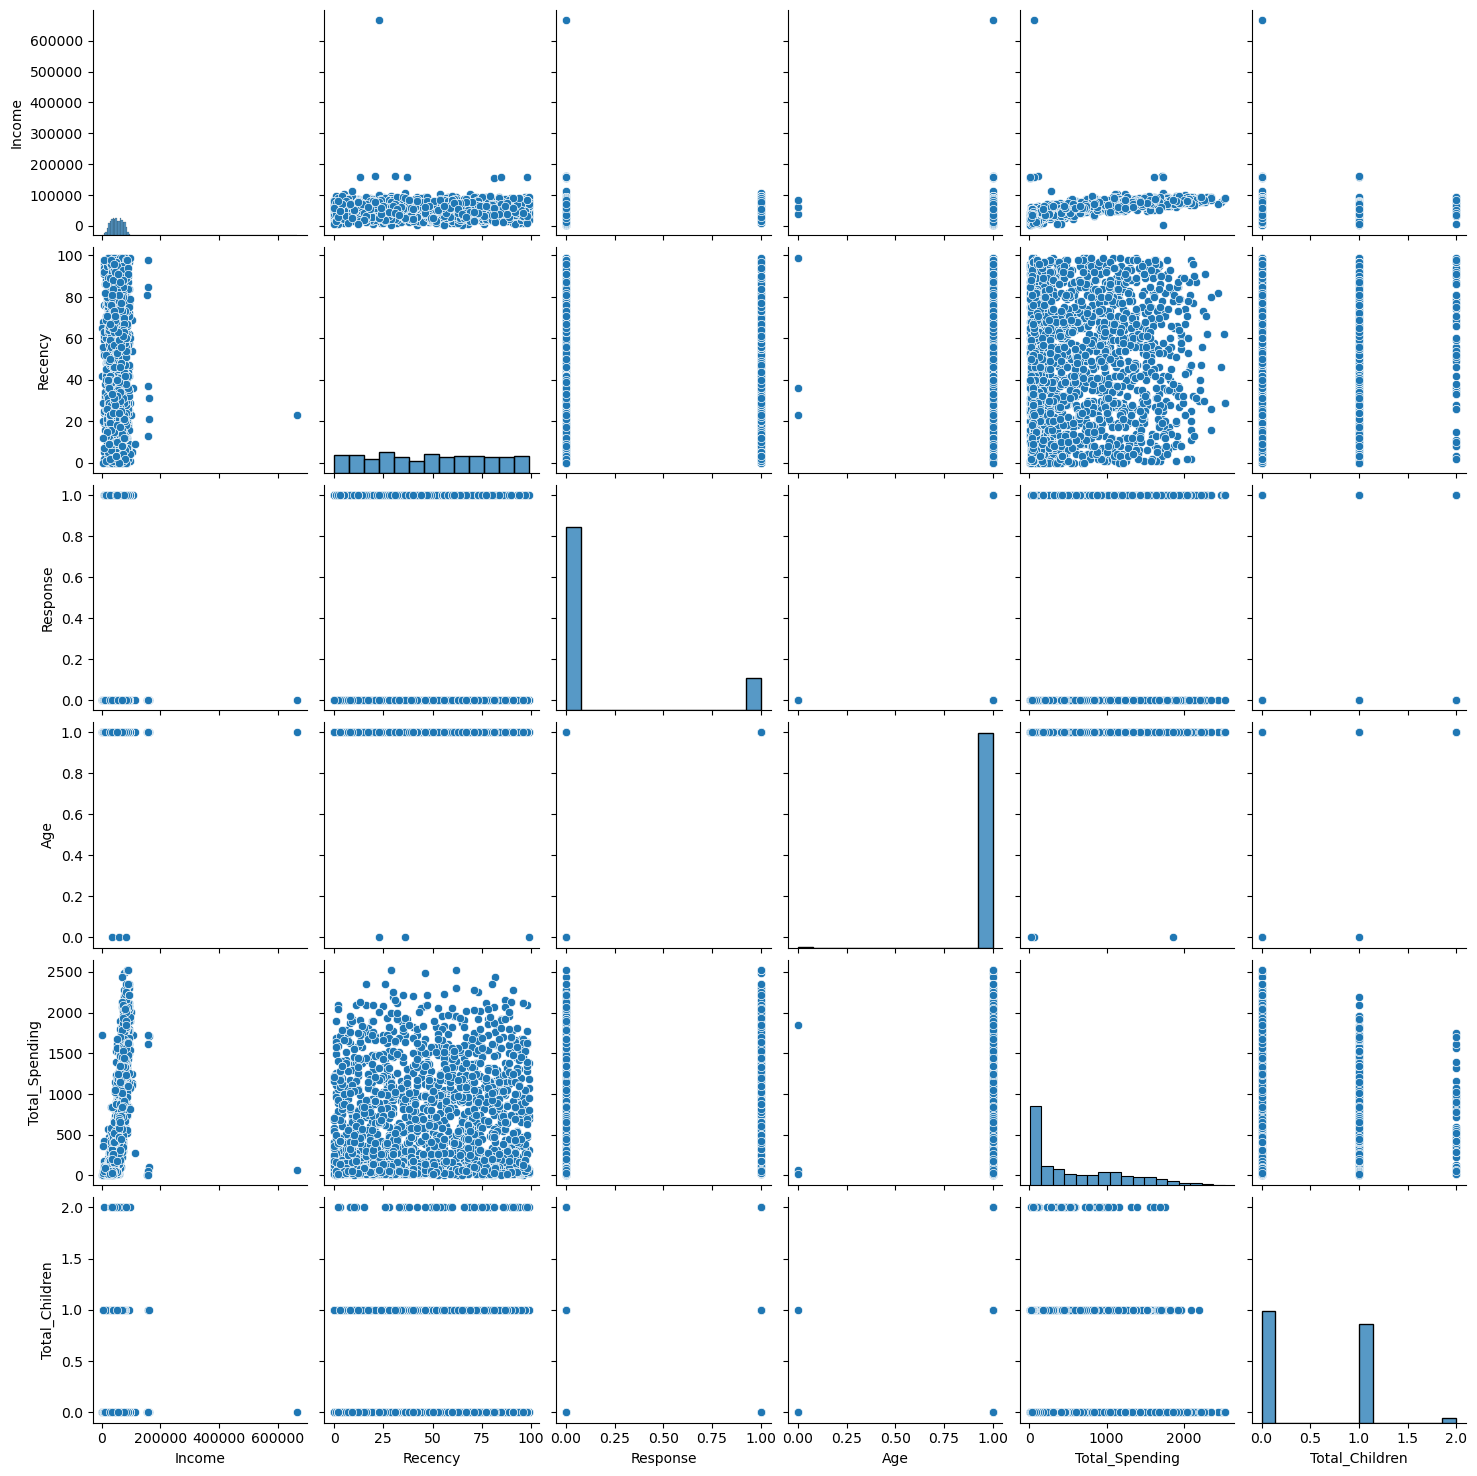

In [48]:
# Handeling Outliers using pair(relative) plots for those cols whose relation cant be sensed just by there names 

col= ["Income","Recency","Response","Age","Total_Spending","Total_Children"]
sns.pairplot(df_cleaned[col])

In [67]:
# Here know we can pin point outliers ,and may of them are cought and will be removed. 


In [52]:
df_cleaned["Age"]

0       True
1       True
2       True
3       True
4       True
        ... 
2235    True
2236    True
2237    True
2238    True
2239    True
Name: Age, Length: 2240, dtype: bool